In [1]:
from src.helpers import BoundingBoxDegree
import pystac_client
import planetary_computer
import numpy as np
import rioxarray
import xarray as xr
from planetary_computer import sign
import xrspatial
from datashader.transfer_functions import shade, stack
from datashader.colors import Elevation

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

east_jutland = BoundingBoxDegree(lon_min=9.674, lat_min=55.618, lon_max=10.953, lat_max=57.774)

In [2]:
search = catalog.search(
    collections=["cop-dem-glo-30"],
    bbox=[east_jutland.lon_min, east_jutland.lat_min, east_jutland.lon_max, east_jutland.lat_max],
    query={"gsd": {"eq": 30}}
)
items = list(search.items())
len(items)

6

In [3]:
rasters = []

for item in items:
    signed = sign(item.assets["data"])
    da = rioxarray.open_rasterio(signed.href)
    rasters.append(da)
# signed = sign(items[0].assets["data"])
# da = rioxarray.open_rasterio(signed.href)
# rasters.append(da)

# Merge all tiles
merged = xr.combine_by_coords(rasters)

data = (
    merged.squeeze()
    .drop_vars("band")
    .coarsen({"y": 1, "x": 1})
    .mean()
).sortby("y")

In [4]:
signed = sign(items[0].assets["data"])
single_data = rioxarray.open_rasterio(signed.href).squeeze().drop_vars("band").load().sortby("y")
single_data.shape

(3600, 2400)

In [5]:
single_data = single_data[2690:3600, :]

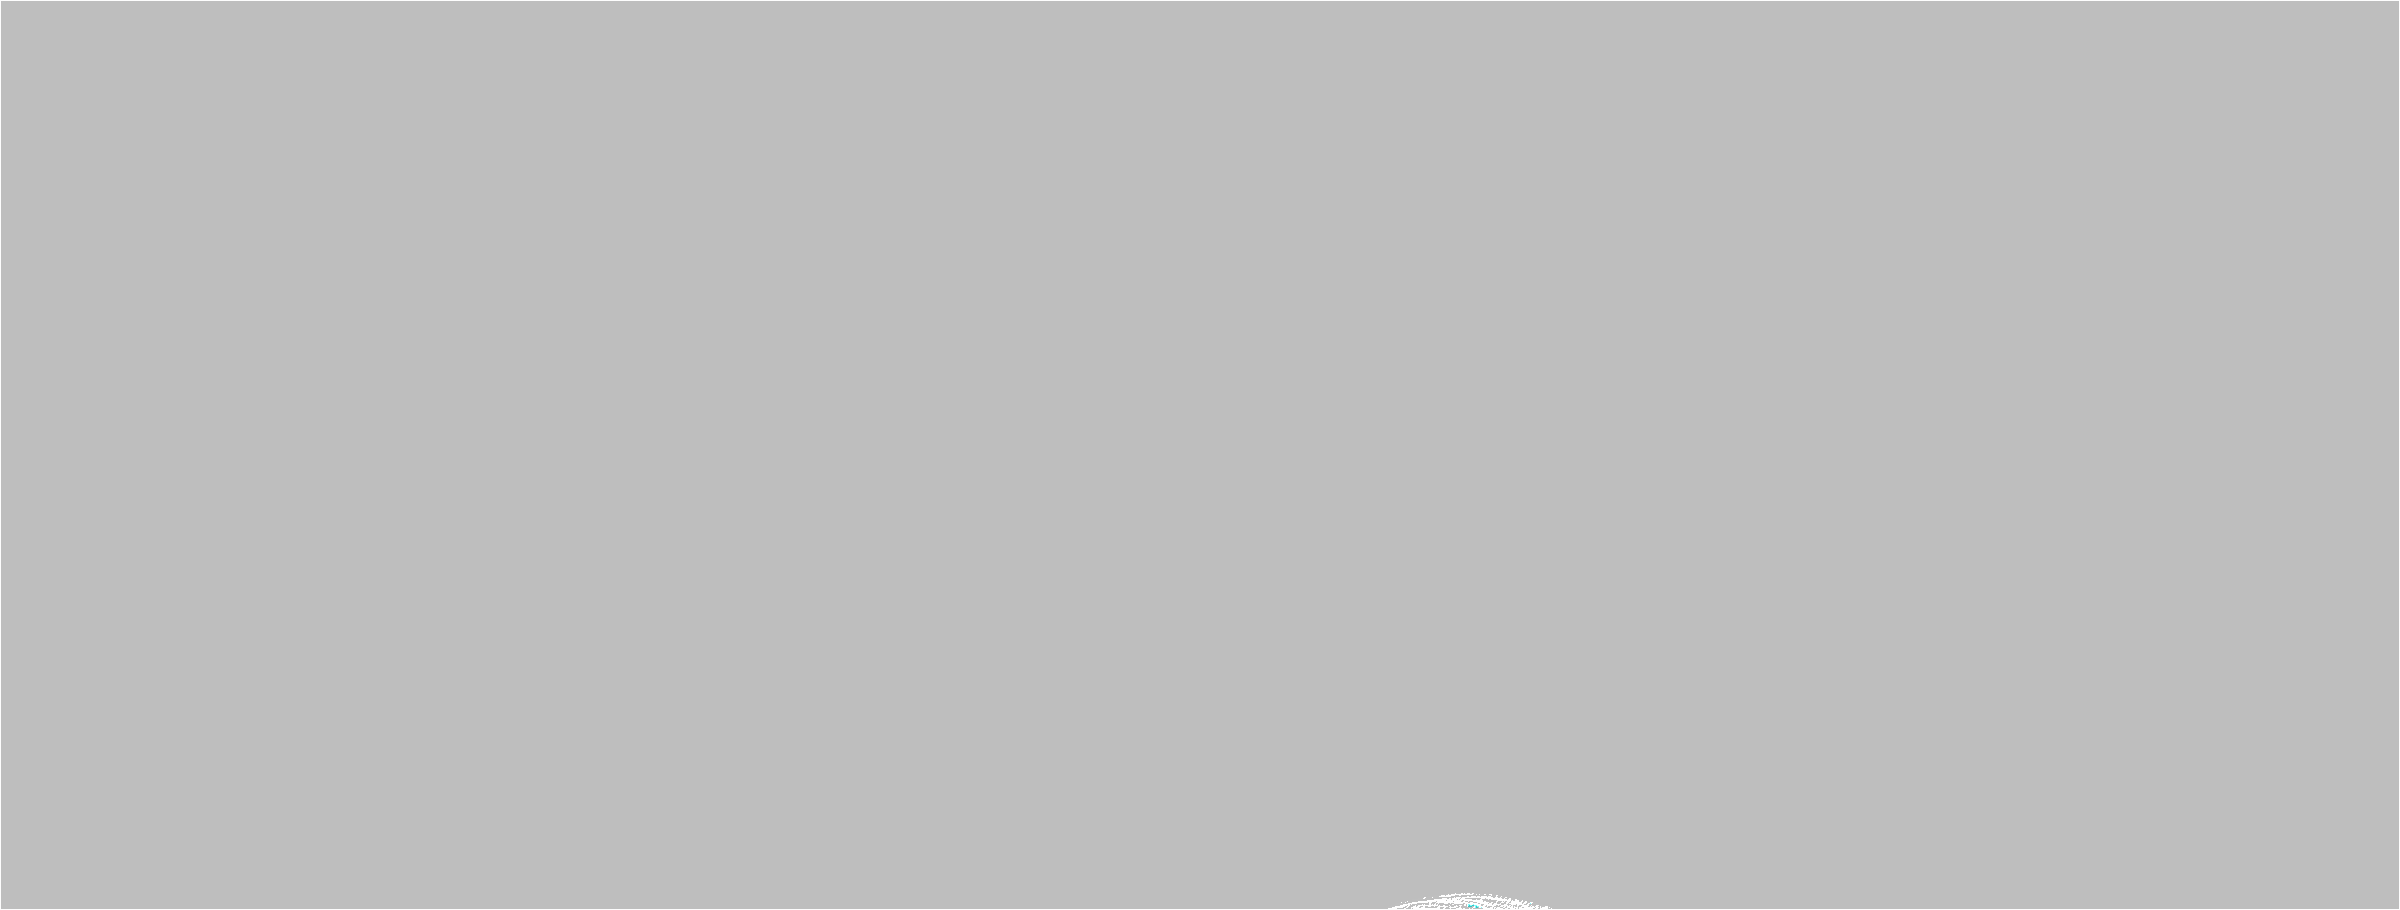

In [6]:
hillshade = xrspatial.hillshade(single_data)
stack(shade(hillshade, cmap=["white", "gray"]), shade(single_data, cmap=Elevation, alpha=128))

In [7]:
np.sum(single_data.values)

np.float32(2642.1077)

In [ ]:
str.join(":", data.rio.crs.to_authority())

'EPSG:4326'